In [ ]:
'''
%pip install py7zr
import py7zr
import glob

with py7zr.SevenZipFile(r"C:/M4/train.7z", 'r') as opened_file:
    opened_file.extractall(r"C:/M4/train")

all_img_paths = glob.glob(r"C:/M4/train/*.png")
'''

In [4]:
%pip install -U transformers torch pillow numpy

Note: you may need to restart the kernel to use updated packages.


In [5]:
from transformers import CLIPProcessor, CLIPModel
import torch
import numpy as np
from PIL import Image

model_16 = CLIPModel.from_pretrained("openai/clip-vit-base-patch16")
model_32 = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor_16 = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")
processor_32 = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def image_embedding(image_path, model, processor):
    """
    Takes an image file path and returns its embedding as a NumPy array.
    """
    # Load and preprocess the image
    image = Image.open(image_path).convert("RGB")
    input = processor(images=image, return_tensors="pt")

    # Extract image features
    with torch.no_grad():
     embeddings = model.get_image_features(**input)
     embeddings = embeddings if isinstance(embeddings, torch.Tensor) else embeddings.pooler_output #for those output that's not tensor yet
    # Normalize and convert to NumPy
    embeddings = embeddings / embeddings.norm(p=2, dim=-1, keepdim=True)
    return embeddings.squeeze().cpu().numpy()


c:\Users\19253\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 35015.58it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 15794.17it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_mode

In [6]:
def create_matrix(image_paths, model=model_16, processor=processor_16): #get the x-train
  embedding_vectors = []
  for image_path in image_paths:
    embedding_vectors.append(image_embedding(image_path, model, processor))

  embedding_matrix = np.stack(embedding_vectors, axis = 0)
  return embedding_matrix


In [7]:
%pip install -U pandas

Note: you may need to restart the kernel to use updated packages.


In [8]:
 #sort using csv
import pandas as pd
import os
df = pd.read_csv(r"C:/M4/trainLabels.csv") #read the csv file in the drive
df = df.sort_values(by=df.columns[1]).reset_index(drop=True) #sort by category
print(df)

df_train = pd.DataFrame()
for label in df['label'].unique():
  df_temp = df[df['label'] == label]
  df_temp_part = df_temp.iloc[:len(df_temp)//2] #take first n images of each category as the initial training set
  df_train = pd.concat([df_train, df_temp_part],ignore_index=True)

img_paths = ('C:/M4/train/' + df_train['id'].astype(str) + '.png').tolist()
img_paths

          id     label
0      29514  airplane
1      16837  airplane
2      32317  airplane
3      32319  airplane
4      32327  airplane
...      ...       ...
49995  13796     truck
49996  25995     truck
49997  36911     truck
49998  21519     truck
49999  25649     truck

[50000 rows x 2 columns]


['C:/M4/train/29514.png',
 'C:/M4/train/16837.png',
 'C:/M4/train/32317.png',
 'C:/M4/train/32319.png',
 'C:/M4/train/32327.png',
 'C:/M4/train/32342.png',
 'C:/M4/train/32347.png',
 'C:/M4/train/16832.png',
 'C:/M4/train/3941.png',
 'C:/M4/train/32364.png',
 'C:/M4/train/3939.png',
 'C:/M4/train/32366.png',
 'C:/M4/train/16826.png',
 'C:/M4/train/32370.png',
 'C:/M4/train/32377.png',
 'C:/M4/train/32379.png',
 'C:/M4/train/32399.png',
 'C:/M4/train/32402.png',
 'C:/M4/train/32310.png',
 'C:/M4/train/16839.png',
 'C:/M4/train/3952.png',
 'C:/M4/train/16841.png',
 'C:/M4/train/32207.png',
 'C:/M4/train/32218.png',
 'C:/M4/train/32219.png',
 'C:/M4/train/3972.png',
 'C:/M4/train/32221.png',
 'C:/M4/train/16867.png',
 'C:/M4/train/32233.png',
 'C:/M4/train/32234.png',
 'C:/M4/train/32404.png',
 'C:/M4/train/32248.png',
 'C:/M4/train/32252.png',
 'C:/M4/train/3963.png',
 'C:/M4/train/32257.png',
 'C:/M4/train/32264.png',
 'C:/M4/train/32268.png',
 'C:/M4/train/32284.png',
 'C:/M4/train/322

In [9]:
"""
df['class'] = None

for idx, label in enumerate(df["label"].unique()): #turn string into categories number
    df.loc[df["label"] == label, "class"] = idx

label_list = df['class'].astype(int)
"""

df_train['class'] = None

for idx, label in enumerate(df_train["label"].unique()): #turn string into categories number (from airplane,automobile,...,truck to 0,1,2,...,9)
    df_train.loc[df_train["label"] == label, "class"] = idx

label_list = df_train['class'].astype(int)

In [ ]:
df_train

In [10]:
import numpy as np
def one_hot_encoded_labels_matrix(labels_list): # grab category list and output elementary-like matrix (y-train)

    num_labels = len(np.unique(labels_list)) # number of categories
    num_samples = len(labels_list)

    Y_onehot = np.zeros((num_samples, num_labels)) # create a zeros matrix
    for sample_idx, sample_label in enumerate(labels_list):

        assert sample_label < num_labels,  f"{sample_label} should be between 0 and {num_labels-1}"
        Y_onehot[sample_idx,sample_label] = 1

    return Y_onehot

In [50]:
def one_hot_encoded_labels_matrix_same_class(labels_list, num_labels): # grab category list and output elementary-like matrix (y-train)

    num_samples = len(labels_list)

    Y_onehot = np.zeros((num_samples, num_labels)) # create a zeros matrix
    for sample_idx, sample_label in enumerate(labels_list):

        assert sample_label < num_labels,  f"{sample_label} should be between 0 and {num_labels-1}"
        Y_onehot[sample_idx,sample_label] = 1

    return Y_onehot

In [ ]:
x_train_16 = create_matrix(img_paths, model_16, processor_16)

In [ ]:
x_train_32 = create_matrix(img_paths, model_32, processor_32)

In [ ]:
y_train = one_hot_encoded_labels_matrix(label_list)

In [ ]:
x_train_16_tensor = torch.tensor(x_train_16, dtype = torch.float32) #turn into type that model use
x_train_32_tensor = torch.tensor(x_train_32, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train, dtype = torch.float32)

In [ ]:
torch.save(x_train_16_tensor, 'C:/M4/Matrices/x_train_16_tensor.pt')
torch.save(x_train_32_tensor, 'C:/M4/Matrices/x_train_32_tensor.pt')
torch.save(y_train_tensor, 'C:/M4/Matrices/y_train_tensor.pt')

In [11]:
x_train_16_tensor = torch.load('C:/M4/Matrices/x_train_16_tensor.pt')
x_train_32_tensor = torch.load('C:/M4/Matrices/x_train_32_tensor.pt')
y_train_tensor = torch.load('C:/M4/Matrices/y_train_tensor.pt')

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

def model_fit_pytorch(x_train, y_train, model,loss_criterion = nn.MSELoss(),epochs=1000, lr=0.01, log_interval=100):

    optimizer = optim.SGD(model.parameters(), lr = lr) # SGD is (Stochastic) Gradient Descent

    loss_history = []
    for epoch in range(epochs):

        model.train() # enter training mode
        optimizer.zero_grad() # reset the gradients of all model parameters before computing new gradients

        y_pred = model(x_train)# predict output based on the model

        # Compute loss
        loss = loss_criterion(y_pred, y_train)
        loss.backward() #derivative with respect to each initial variable
        optimizer.step() #perform changes
        loss_history.append(loss.item()) #record loss

        if log_interval and epoch % log_interval == 0:
            print(f"Epoch [{epoch}/{epochs}], Loss: {loss_history[-1]:.4f}") #.4f -> to the fourth decimal place

    return model, loss_history

In [ ]:
x_train_16_tensor.shape

In [ ]:
y_train_tensor.shape

In [13]:
#nn.Sequential: wraps layers in order (since one linear layer in this case, not required)
#nn.Linear: linear model, y=xW^t+b (x=each row of x_train_tensor)
formula_16 = nn.Sequential(nn.Linear(x_train_16_tensor.shape[1],y_train_tensor.shape[1]))
formula_32 = nn.Sequential(nn.Linear(x_train_16_tensor.shape[1],y_train_tensor.shape[1]))
trained_model_16,loss_history_16 = model_fit_pytorch(x_train_16_tensor, y_train_tensor, formula_16, loss_criterion = nn.MSELoss(),epochs = 3000, lr = 5.5, log_interval=100) #training iterations


Epoch [0/3000], Loss: 0.1026
Epoch [100/3000], Loss: 0.0367
Epoch [200/3000], Loss: 0.0255
Epoch [300/3000], Loss: 0.0211
Epoch [400/3000], Loss: 0.0190
Epoch [500/3000], Loss: 0.0178
Epoch [600/3000], Loss: 0.0171
Epoch [700/3000], Loss: 0.0166
Epoch [800/3000], Loss: 0.0162
Epoch [900/3000], Loss: 0.0160
Epoch [1000/3000], Loss: 0.0158
Epoch [1100/3000], Loss: 0.0156
Epoch [1200/3000], Loss: 0.0155
Epoch [1300/3000], Loss: 0.0154
Epoch [1400/3000], Loss: 0.0153
Epoch [1500/3000], Loss: 0.0152
Epoch [1600/3000], Loss: 0.0151
Epoch [1700/3000], Loss: 0.0150
Epoch [1800/3000], Loss: 0.0150
Epoch [1900/3000], Loss: 0.0149
Epoch [2000/3000], Loss: 0.0148
Epoch [2100/3000], Loss: 0.0148
Epoch [2200/3000], Loss: 0.0147
Epoch [2300/3000], Loss: 0.0147
Epoch [2400/3000], Loss: 0.0146
Epoch [2500/3000], Loss: 0.0146
Epoch [2600/3000], Loss: 0.0146
Epoch [2700/3000], Loss: 0.0145
Epoch [2800/3000], Loss: 0.0145
Epoch [2900/3000], Loss: 0.0145


In [14]:
trained_model_32,loss_history_32 = model_fit_pytorch(x_train_32_tensor, y_train_tensor, formula_32, loss_criterion = nn.MSELoss(),epochs = 3000, lr = 5.5, log_interval=100) #training iterations

Epoch [0/3000], Loss: 0.0997
Epoch [100/3000], Loss: 0.0364
Epoch [200/3000], Loss: 0.0265
Epoch [300/3000], Loss: 0.0227
Epoch [400/3000], Loss: 0.0208
Epoch [500/3000], Loss: 0.0198
Epoch [600/3000], Loss: 0.0191
Epoch [700/3000], Loss: 0.0186
Epoch [800/3000], Loss: 0.0183
Epoch [900/3000], Loss: 0.0180
Epoch [1000/3000], Loss: 0.0178
Epoch [1100/3000], Loss: 0.0176
Epoch [1200/3000], Loss: 0.0175
Epoch [1300/3000], Loss: 0.0174
Epoch [1400/3000], Loss: 0.0173
Epoch [1500/3000], Loss: 0.0172
Epoch [1600/3000], Loss: 0.0171
Epoch [1700/3000], Loss: 0.0170
Epoch [1800/3000], Loss: 0.0169
Epoch [1900/3000], Loss: 0.0169
Epoch [2000/3000], Loss: 0.0168
Epoch [2100/3000], Loss: 0.0168
Epoch [2200/3000], Loss: 0.0167
Epoch [2300/3000], Loss: 0.0167
Epoch [2400/3000], Loss: 0.0166
Epoch [2500/3000], Loss: 0.0166
Epoch [2600/3000], Loss: 0.0166
Epoch [2700/3000], Loss: 0.0165
Epoch [2800/3000], Loss: 0.0165
Epoch [2900/3000], Loss: 0.0165


In [15]:
%pip install -U seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

def loss_history_plot(loss_history_16, loss_history_32, epochs = None):

    #16
    fig, ax = plt.subplots(1,2,figsize=(12, 5))
    # Loss curve
    ax[0].plot(np.arange(epochs), loss_history_16, marker = "o", color='green', alpha=0.8)
    ax[0].set_yscale('log')
    ax[0].set_title('Loss Over Epochs (Log Scale) CLIP16')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].grid(True)

    y_last_16 = loss_history_16[-1]
    x_last_16 = epochs
    ax[0].scatter(x_last_16,y_last_16)
    ax[0].text(x_last_16, y_last_16, f"final loss: {y_last_16:.4f}\n, total epochs: {x_last_16}")

    # Loss curve
    ax[1].plot(np.arange(epochs), loss_history_32, marker = "o", color='green', alpha=0.8)
    ax[1].set_yscale('log')
    ax[1].set_title('Loss Over Epochs (Log Scale) CLIP32')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Loss')
    ax[1].grid(True)

    y_last_32 = loss_history_32[-1]
    x_last_32 = epochs
    ax[1].scatter(x_last_32,y_last_32)
    ax[1].text(x_last_32, y_last_32, f"final loss: {y_last_32:.4f}\n, total epochs: {x_last_32}")

    plt.tight_layout()
    plt.show()

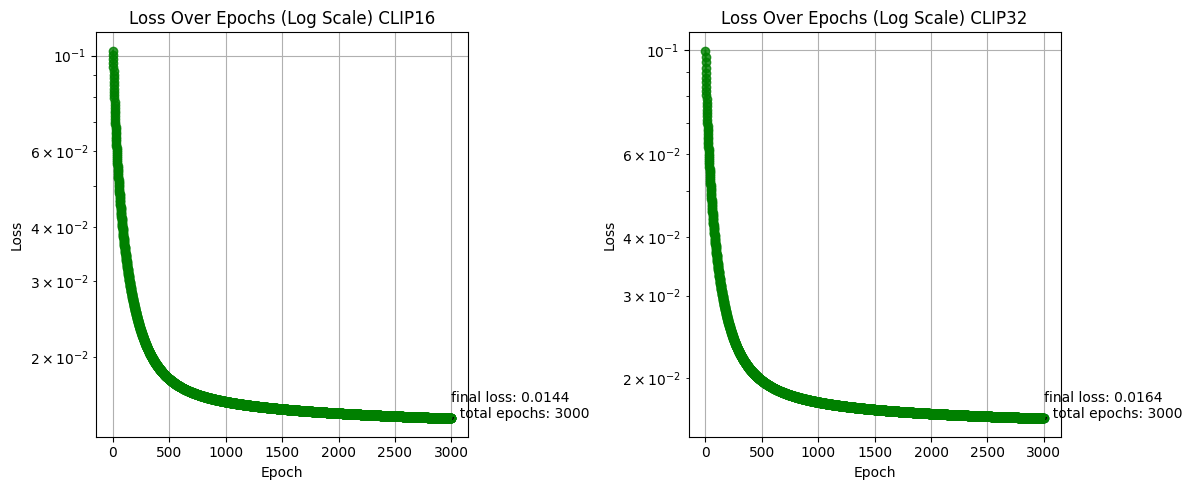

In [17]:
loss_history_plot(loss_history_16, loss_history_32, 3000)

In [18]:
def pytorch_model_multiclass_inference(model,X_tensor): #
    model.eval()

    with torch.no_grad():
        Y_predicted = model(X_tensor)
        predicted_labels = torch.argmax(Y_predicted,dim = 1).detach().numpy() #argmax: find the index of maximum values; dim=1: across each row
        #.detach basically remove gradient tracked, since we use no_grad, it's not necessary
    return Y_predicted, predicted_labels

In [19]:
df_test = pd.DataFrame()
for label in df['label'].unique():
  df_temp = df[df['label'] == label]
  df_temp_part = df_temp.iloc[len(df_temp)//2:len(df_temp)//10*7]
  df_test = pd.concat([df_test, df_temp_part],ignore_index=True)

img_paths_test = ('C:/M4/train/'+df_test['id'].astype(str)+'.png').tolist()
img_paths_test



['C:/M4/train/19741.png',
 'C:/M4/train/6762.png',
 'C:/M4/train/26377.png',
 'C:/M4/train/26392.png',
 'C:/M4/train/19665.png',
 'C:/M4/train/19731.png',
 'C:/M4/train/26413.png',
 'C:/M4/train/26417.png',
 'C:/M4/train/26422.png',
 'C:/M4/train/19717.png',
 'C:/M4/train/26428.png',
 'C:/M4/train/26431.png',
 'C:/M4/train/19698.png',
 'C:/M4/train/19683.png',
 'C:/M4/train/19729.png',
 'C:/M4/train/26593.png',
 'C:/M4/train/26050.png',
 'C:/M4/train/26041.png',
 'C:/M4/train/6703.png',
 'C:/M4/train/25713.png',
 'C:/M4/train/25715.png',
 'C:/M4/train/19989.png',
 'C:/M4/train/25720.png',
 'C:/M4/train/25747.png',
 'C:/M4/train/25749.png',
 'C:/M4/train/19983.png',
 'C:/M4/train/5372.png',
 'C:/M4/train/25763.png',
 'C:/M4/train/25764.png',
 'C:/M4/train/25787.png',
 'C:/M4/train/25788.png',
 'C:/M4/train/25790.png',
 'C:/M4/train/25793.png',
 'C:/M4/train/25798.png',
 'C:/M4/train/19975.png',
 'C:/M4/train/20003.png',
 'C:/M4/train/25697.png',
 'C:/M4/train/20015.png',
 'C:/M4/train/2

In [20]:
df_test

,id,label
0,19741,airplane
1,6762,airplane
2,26377,airplane
3,26392,airplane
4,19665,airplane
...,...,...
9995,22368,truck
9996,23404,truck
9997,7584,truck
9998,23401,truck


In [21]:
x_test_16 = create_matrix(img_paths_test, model_16, processor_16)
x_test_32 = create_matrix(img_paths_test, model_32, processor_32)

KeyboardInterrupt: 

In [ ]:
x_test_16_tensor = torch.tensor(x_test_16,dtype = torch.float32)
x_test_32_tensor = torch.tensor(x_test_32,dtype = torch.float32)

In [ ]:
torch.save(x_test_16_tensor, 'C:/M4/Matrices/x_test_16_tensor.pt')
torch.save(x_test_32_tensor, 'C:/M4/Matrices/x_test_32_tensor.pt')

In [22]:
x_test_16_tensor = torch.load('C:/M4/Matrices/x_test_16_tensor.pt')
x_test_32_tensor = torch.load('C:/M4/Matrices/x_test_32_tensor.pt')

In [23]:
predicted_matrix_16, predicted_label_list_16 = pytorch_model_multiclass_inference(trained_model_16,x_test_16_tensor)
predicted_matrix_32, predicted_label_list_32 = pytorch_model_multiclass_inference(trained_model_32,x_test_32_tensor)

In [24]:
torch.save(predicted_matrix_16, 'C:/M4/Matrices/predicted_matrix_16.pt')
torch.save(predicted_matrix_32, 'C:/M4/Matrices/predicted_matrix_32.pt')

predicted_matrix_16 = torch.load('C:/M4/Matrices/predicted_matrix_16.pt')
predicted_matrix_32 = torch.load('C:/M4/Matrices/predicted_matrix_32.pt')

In [25]:
df_test['class'] = None

for idx, label in enumerate(df_test["label"].unique()): #turn string into categories number
    df_test.loc[df_test["label"] == label, "class"] = idx

real_label_list = df_test['class'].astype(int)

In [26]:
df_hold = pd.DataFrame()
for label in df['label'].unique():
  df_temp = df[df['label'] == label]
  df_temp_part = df_temp.iloc[len(df_temp)//10*7:]
  df_hold = pd.concat([df_hold, df_temp_part],ignore_index=True)

img_paths_hold = ('C:/M4/train/'+df_hold['id'].astype(str)+'.png').tolist()
img_paths_hold

['C:/M4/train/9752.png',
 'C:/M4/train/48730.png',
 'C:/M4/train/48870.png',
 'C:/M4/train/48892.png',
 'C:/M4/train/9667.png',
 'C:/M4/train/48909.png',
 'C:/M4/train/9658.png',
 'C:/M4/train/48925.png',
 'C:/M4/train/48927.png',
 'C:/M4/train/48931.png',
 'C:/M4/train/48940.png',
 'C:/M4/train/234.png',
 'C:/M4/train/48959.png',
 'C:/M4/train/9620.png',
 'C:/M4/train/48969.png',
 'C:/M4/train/8995.png',
 'C:/M4/train/48972.png',
 'C:/M4/train/9617.png',
 'C:/M4/train/9615.png',
 'C:/M4/train/48862.png',
 'C:/M4/train/48860.png',
 'C:/M4/train/48857.png',
 'C:/M4/train/48853.png',
 'C:/M4/train/48749.png',
 'C:/M4/train/9719.png',
 'C:/M4/train/48778.png',
 'C:/M4/train/48779.png',
 'C:/M4/train/48783.png',
 'C:/M4/train/48789.png',
 'C:/M4/train/265.png',
 'C:/M4/train/48793.png',
 'C:/M4/train/48493.png',
 'C:/M4/train/9715.png',
 'C:/M4/train/9697.png',
 'C:/M4/train/9688.png',
 'C:/M4/train/48843.png',
 'C:/M4/train/48845.png',
 'C:/M4/train/9672.png',
 'C:/M4/train/48848.png',
 '

In [ ]:
x_hold_16 = create_matrix(img_paths_hold, model_16, processor_16)
x_hold_32 = create_matrix(img_paths_hold, model_32, processor_32)

In [ ]:
x_hold_16_tensor = torch.tensor(x_hold_16,dtype = torch.float32)
x_hold_32_tensor = torch.tensor(x_hold_32,dtype = torch.float32)

In [ ]:
torch.save(x_hold_16_tensor, 'C:/M4/Matrices/x_hold_16_tensor.pt')
torch.save(x_hold_32_tensor, 'C:/M4/Matrices/x_hold_32_tensor.pt')

In [27]:
x_hold_16_tensor = torch.load('C:/M4/Matrices/x_hold_16_tensor.pt')
x_hold_32_tensor = torch.load('C:/M4/Matrices/x_hold_32_tensor.pt')

In [32]:
cat_idx = np.where(df_hold['label'].to_numpy() == 3)[0]
deer_idx = np.where(df_hold['label'].to_numpy() == 4)[0]

In [35]:
df_cat = df_hold[(df_hold['label'].to_numpy() == 3)]
df_deer = df_hold[(df_hold['label'].to_numpy() == 4)]

In [36]:
df_cat['class'] = None
df_deer['class'] = None
df_cat['class'] = '3'
df_deer['class'] = '4'

In [39]:
label_list_cat = df_cat['class'].astype(int)
label_list_deer = df_deer['class'].astype(int)

In [37]:
df_hold['class'] = None

for idx, label in enumerate(df_hold["label"].unique()): #turn string into categories number
    df_hold.loc[df_hold["label"] == label, "class"] = idx

label_list2 = df_hold['class'].astype(int)

In [38]:
x_hold_out_cat = x_hold_16_tensor [cat_idx]
x_hold_out_deer = x_hold_32_tensor [deer_idx]

In [61]:
torch.save(x_hold_out_cat, 'C:/M4/Matrices/x_hold_out_cat.pt')
torch.save(x_hold_out_deer, 'C:/M4/Matrices/x_hold_out_deer.pt')

In [63]:
x_hold_out_cat = torch.load('C:/M4/Matrices/x_hold_out_cat.pt')
x_hold_out_deer = torch.load('C:/M4/Matrices/x_hold_out_deer.pt')

In [51]:
y_hold_out_cat = one_hot_encoded_labels_matrix_same_class(label_list_cat,10)
y_hold_out_deer =one_hot_encoded_labels_matrix_same_class(label_list_deer,10)

In [53]:
y_hold_out_cat_tensor = torch.tensor(y_hold_out_cat,dtype = torch.float32)
y_hold_out_deer_tensor = torch.tensor(y_hold_out_deer,dtype = torch.float32)

In [ ]:
df_hold['class'] = None

for idx, label in enumerate(df_hold["label"].unique()): #turn string into categories number
    df_hold.loc[df_hold["label"] == label, "class"] = idx

label_list2 = df_hold['class'].astype(int)

In [47]:
y_hold = one_hot_encoded_labels_matrix(label_list2)

In [48]:
y_hold_tensor = torch.tensor(y_hold,dtype = torch.float32)

In [ ]:
def accuracy(y_pred_label, y_label):
    return np.mean(y_pred_label == y_label)

In [ ]:
accuracy_5to2_16 = accuracy(predicted_label_list_16,real_label_list)
accuracy_5to2_32 = accuracy(predicted_label_list_32,real_label_list)

In [65]:
def compute_confusion_matrix(correct_labels, predicted_labels):
    unique_labels = np.unique(correct_labels)
    num_labels = len(unique_labels)

    confusion_matrix = np.zeros((num_labels, num_labels))

    for i, unique_label in enumerate(unique_labels):
        true_idxs = (correct_labels == unique_label) #compare every label in correct_labels to a unique label, output a list of T or F
        #true_idxs gives the positions that have label as unique_label
        num_true = np.sum(true_idxs) #count how many trues

        for j, pred_label in enumerate(unique_labels):
            num_pred_as_label = np.sum(predicted_labels[true_idxs] == pred_label)
            if num_true > 0.0:
                confusion_matrix[i, j] = num_pred_as_label/num_true

    return confusion_matrix, unique_labels

In [ ]:
confusion_matrix_16, categories = compute_confusion_matrix(real_label_list, predicted_label_list_16)
confusion_matrix_32, categories = compute_confusion_matrix(real_label_list, predicted_label_list_32)

In [66]:


def plot_confusion_matrix_heatmap(conf_matrix, class_labels=None, title="Confusion Matrix"):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt=".2f", cmap="cividis",  # colorblind friendly palette
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
plot_confusion_matrix_heatmap(confusion_matrix_16, class_labels=df['label'].unique().astype(str), title="Confusion Matrix (clip-vit-base-patch16) 5:2")

In [ ]:
plot_confusion_matrix_heatmap(confusion_matrix_32, class_labels=df['label'].unique().astype(str), title="Confusion Matrix (clip-vit-base-patch32) 5:2")

In [49]:
x_train_final_16_tensor = torch.cat((x_train_16_tensor, x_hold_16_tensor), dim=0)
x_train_final_32_tensor = torch.cat((x_train_32_tensor, x_hold_32_tensor), dim=0)
y_train_final_tensor = torch.cat((y_train_tensor, y_hold_tensor), dim=0)

In [41]:
x_train_16_tensor_with_cat = torch.cat((x_train_16_tensor, x_hold_out_cat), dim=0)
x_train_32_tensor_with_deer = torch.cat((x_train_32_tensor, x_hold_out_deer), dim=0)

In [54]:
y_train_tensor_with_cat = torch.cat((y_train_tensor, y_hold_out_cat_tensor), dim=0)
y_train_tensor_with_deer = torch.cat((y_train_tensor, y_hold_out_deer_tensor), dim=0)

In [56]:
formula_16_with_cat = nn.Sequential(nn.Linear(x_train_16_tensor.shape[1],y_train_tensor.shape[1]))
formula_32_with_deer = nn.Sequential(nn.Linear(x_train_16_tensor.shape[1],y_train_tensor.shape[1]))
trained_model_16_with_cat,loss_history_16_with_cat = model_fit_pytorch(x_train_16_tensor_with_cat, y_train_tensor_with_cat, formula_16_with_cat, loss_criterion = nn.MSELoss(),epochs = 3000, lr = 5.5, log_interval=100) #training iterations

Epoch [0/3000], Loss: 0.1042
Epoch [100/3000], Loss: 0.0368
Epoch [200/3000], Loss: 0.0256
Epoch [300/3000], Loss: 0.0212
Epoch [400/3000], Loss: 0.0190
Epoch [500/3000], Loss: 0.0178
Epoch [600/3000], Loss: 0.0171
Epoch [700/3000], Loss: 0.0166
Epoch [800/3000], Loss: 0.0163
Epoch [900/3000], Loss: 0.0160
Epoch [1000/3000], Loss: 0.0158
Epoch [1100/3000], Loss: 0.0156
Epoch [1200/3000], Loss: 0.0155
Epoch [1300/3000], Loss: 0.0154
Epoch [1400/3000], Loss: 0.0153
Epoch [1500/3000], Loss: 0.0152
Epoch [1600/3000], Loss: 0.0151
Epoch [1700/3000], Loss: 0.0150
Epoch [1800/3000], Loss: 0.0150
Epoch [1900/3000], Loss: 0.0149
Epoch [2000/3000], Loss: 0.0148
Epoch [2100/3000], Loss: 0.0148
Epoch [2200/3000], Loss: 0.0147
Epoch [2300/3000], Loss: 0.0147
Epoch [2400/3000], Loss: 0.0146
Epoch [2500/3000], Loss: 0.0146
Epoch [2600/3000], Loss: 0.0146
Epoch [2700/3000], Loss: 0.0145
Epoch [2800/3000], Loss: 0.0145
Epoch [2900/3000], Loss: 0.0145


In [57]:
trained_model_32_with_deer,loss_history_32_with_deer = model_fit_pytorch(x_train_32_tensor_with_deer, y_train_tensor_with_deer, formula_32_with_deer, loss_criterion = nn.MSELoss(),epochs = 3000, lr = 5.5, log_interval=100) #training iterations

Epoch [0/3000], Loss: 0.1004
Epoch [100/3000], Loss: 0.0364
Epoch [200/3000], Loss: 0.0265
Epoch [300/3000], Loss: 0.0227
Epoch [400/3000], Loss: 0.0208
Epoch [500/3000], Loss: 0.0198
Epoch [600/3000], Loss: 0.0191
Epoch [700/3000], Loss: 0.0186
Epoch [800/3000], Loss: 0.0182
Epoch [900/3000], Loss: 0.0180
Epoch [1000/3000], Loss: 0.0178
Epoch [1100/3000], Loss: 0.0176
Epoch [1200/3000], Loss: 0.0175
Epoch [1300/3000], Loss: 0.0173
Epoch [1400/3000], Loss: 0.0172
Epoch [1500/3000], Loss: 0.0171
Epoch [1600/3000], Loss: 0.0171
Epoch [1700/3000], Loss: 0.0170
Epoch [1800/3000], Loss: 0.0169
Epoch [1900/3000], Loss: 0.0169
Epoch [2000/3000], Loss: 0.0168
Epoch [2100/3000], Loss: 0.0168
Epoch [2200/3000], Loss: 0.0167
Epoch [2300/3000], Loss: 0.0167
Epoch [2400/3000], Loss: 0.0166
Epoch [2500/3000], Loss: 0.0166
Epoch [2600/3000], Loss: 0.0166
Epoch [2700/3000], Loss: 0.0165
Epoch [2800/3000], Loss: 0.0165
Epoch [2900/3000], Loss: 0.0165


In [59]:
predicted_matrix_16_with_cat, predicted_label_list_16_with_cat = pytorch_model_multiclass_inference(trained_model_16_with_cat,x_test_16_tensor)
predicted_matrix_32_with_deer, predicted_label_list_32_with_deer = pytorch_model_multiclass_inference(trained_model_32_with_deer,x_test_32_tensor)

In [60]:
torch.save(predicted_matrix_16_with_cat, 'C:/M4/Matrices/predicted_matrix_16_with_cat.pt')
torch.save(predicted_matrix_32_with_deer, 'C:/M4/Matrices/predicted_matrix_32_with_deer.pt')

predicted_matrix_16_final = torch.load('C:/M4/Matrices/predicted_matrix_16_with_cat.pt')
predicted_matrix_32_final = torch.load('C:/M4/Matrices/predicted_matrix_32_with_deer.pt')

In [67]:
confusion_matrix_16_with_cat, categories = compute_confusion_matrix(real_label_list, predicted_label_list_16_with_cat)
confusion_matrix_32_with_deer, categories = compute_confusion_matrix(real_label_list, predicted_label_list_32_with_deer)

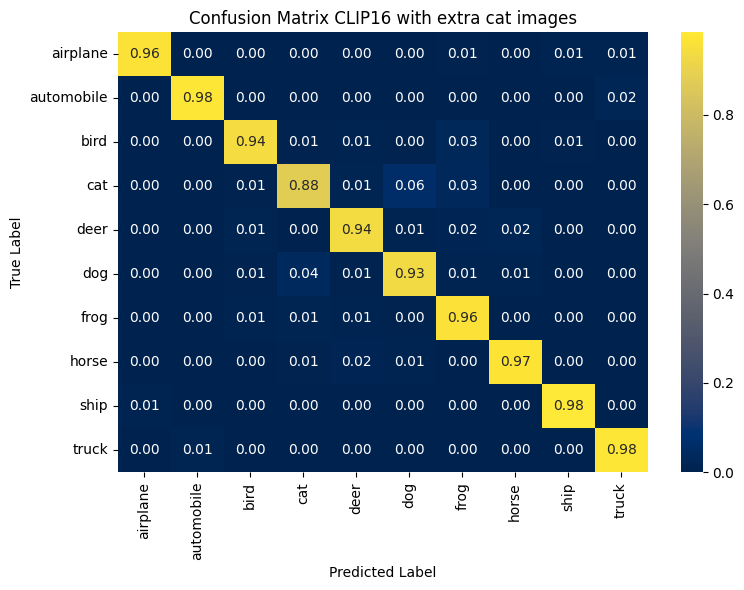

In [68]:
plot_confusion_matrix_heatmap(confusion_matrix_16_with_cat, class_labels=df['label'].unique().astype(str), title="Confusion Matrix CLIP16 with extra cat images")

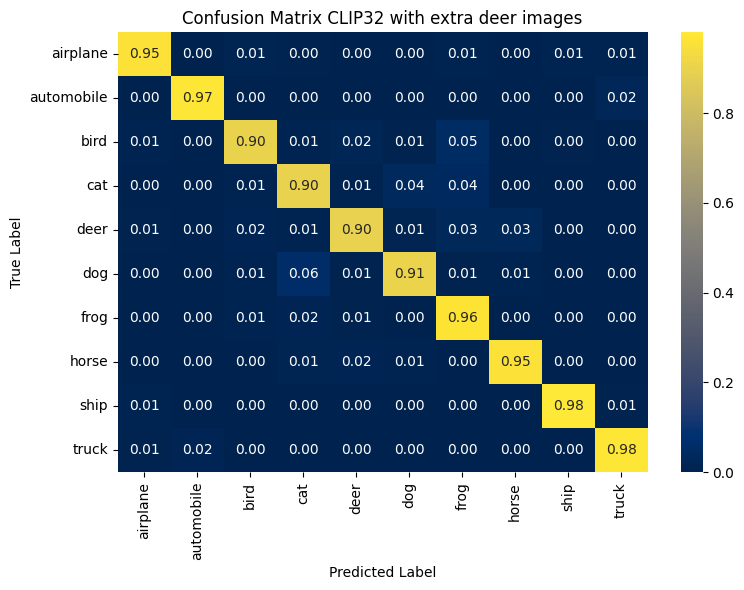

In [69]:
plot_confusion_matrix_heatmap(confusion_matrix_32_with_deer, class_labels=df['label'].unique().astype(str), title="Confusion Matrix CLIP32 with extra deer images")

In [75]:
formula_16_final = nn.Sequential(nn.Linear(x_train_16_tensor.shape[1],y_train_tensor.shape[1]))
formula_32_final = nn.Sequential(nn.Linear(x_train_16_tensor.shape[1],y_train_tensor.shape[1]))
trained_model_16_final,loss_history_16_final = model_fit_pytorch(x_train_final_16_tensor, y_train_final_tensor, formula_16_final, loss_criterion = nn.MSELoss(),epochs = 3000, lr = 5.5, log_interval=100) #training iterations


Epoch [0/3000], Loss: 0.1000
Epoch [100/3000], Loss: 0.0370
Epoch [200/3000], Loss: 0.0257
Epoch [300/3000], Loss: 0.0213
Epoch [400/3000], Loss: 0.0191
Epoch [500/3000], Loss: 0.0179
Epoch [600/3000], Loss: 0.0172
Epoch [700/3000], Loss: 0.0167
Epoch [800/3000], Loss: 0.0163
Epoch [900/3000], Loss: 0.0161
Epoch [1000/3000], Loss: 0.0159
Epoch [1100/3000], Loss: 0.0157
Epoch [1200/3000], Loss: 0.0156
Epoch [1300/3000], Loss: 0.0155
Epoch [1400/3000], Loss: 0.0154
Epoch [1500/3000], Loss: 0.0153
Epoch [1600/3000], Loss: 0.0152
Epoch [1700/3000], Loss: 0.0151
Epoch [1800/3000], Loss: 0.0151
Epoch [1900/3000], Loss: 0.0150
Epoch [2000/3000], Loss: 0.0149
Epoch [2100/3000], Loss: 0.0149
Epoch [2200/3000], Loss: 0.0148
Epoch [2300/3000], Loss: 0.0148
Epoch [2400/3000], Loss: 0.0148
Epoch [2500/3000], Loss: 0.0147
Epoch [2600/3000], Loss: 0.0147
Epoch [2700/3000], Loss: 0.0146
Epoch [2800/3000], Loss: 0.0146
Epoch [2900/3000], Loss: 0.0146


In [76]:
trained_model_32_final,loss_history_32_final = model_fit_pytorch(x_train_final_32_tensor, y_train_final_tensor, formula_32_final, loss_criterion = nn.MSELoss(),epochs = 3000, lr = 5.5, log_interval=100) #training iterations

Epoch [0/3000], Loss: 0.1018
Epoch [100/3000], Loss: 0.0365
Epoch [200/3000], Loss: 0.0266
Epoch [300/3000], Loss: 0.0228
Epoch [400/3000], Loss: 0.0209
Epoch [500/3000], Loss: 0.0199
Epoch [600/3000], Loss: 0.0192
Epoch [700/3000], Loss: 0.0187
Epoch [800/3000], Loss: 0.0184
Epoch [900/3000], Loss: 0.0181
Epoch [1000/3000], Loss: 0.0179
Epoch [1100/3000], Loss: 0.0177
Epoch [1200/3000], Loss: 0.0176
Epoch [1300/3000], Loss: 0.0175
Epoch [1400/3000], Loss: 0.0174
Epoch [1500/3000], Loss: 0.0173
Epoch [1600/3000], Loss: 0.0172
Epoch [1700/3000], Loss: 0.0171
Epoch [1800/3000], Loss: 0.0171
Epoch [1900/3000], Loss: 0.0170
Epoch [2000/3000], Loss: 0.0169
Epoch [2100/3000], Loss: 0.0169
Epoch [2200/3000], Loss: 0.0168
Epoch [2300/3000], Loss: 0.0168
Epoch [2400/3000], Loss: 0.0168
Epoch [2500/3000], Loss: 0.0167
Epoch [2600/3000], Loss: 0.0167
Epoch [2700/3000], Loss: 0.0167
Epoch [2800/3000], Loss: 0.0166
Epoch [2900/3000], Loss: 0.0166


In [77]:
predicted_matrix_16_final, predicted_label_list_16_final = pytorch_model_multiclass_inference(trained_model_16_final,x_test_16_tensor)
predicted_matrix_32_final, predicted_label_list_32_final = pytorch_model_multiclass_inference(trained_model_32_final,x_test_32_tensor)

In [72]:
torch.save(predicted_matrix_16_final, 'C:/M4/Matrices/predicted_matrix_16_final.pt')
torch.save(predicted_matrix_32_final, 'C:/M4/Matrices/predicted_matrix_32_final.pt')

predicted_matrix_16_final = torch.load('C:/M4/Matrices/predicted_matrix_16_final.pt')
predicted_matrix_32_final = torch.load('C:/M4/Matrices/predicted_matrix_32_final.pt')

In [ ]:
accuracy_4to1_16 = accuracy(predicted_label_list_16_final,real_label_list)
accuracy_4to1_32 = accuracy(predicted_label_list_32_final,real_label_list)

In [78]:
confusion_matrix_16_final, categories = compute_confusion_matrix(real_label_list, predicted_label_list_16_final)
confusion_matrix_32_final, categories = compute_confusion_matrix(real_label_list, predicted_label_list_32_final)

In [ ]:
plot_confusion_matrix_heatmap(confusion_matrix_16_final, class_labels=df['label'].unique().astype(str), title="Confusion Matrix (clip-vit-base-patch16) 4:1")

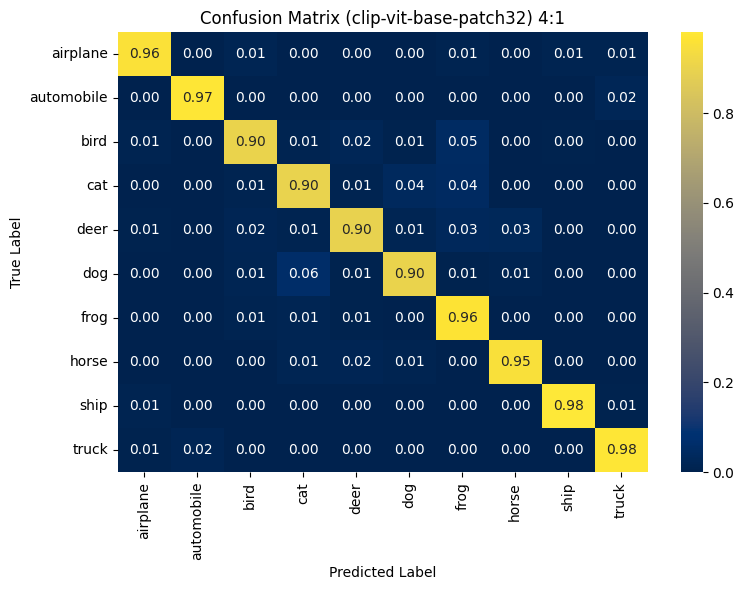

In [79]:
plot_confusion_matrix_heatmap(confusion_matrix_32_final, class_labels=df['label'].unique().astype(str), title="Confusion Matrix (clip-vit-base-patch32) 4:1")

In [ ]:
accuracy_5to2_16 #25000 train w/ 10000 test model 16

In [ ]:
accuracy_5to2_32 #25000 train w/ 10000 test model 32

In [ ]:
accuracy_4to1_16 #40000 train w/ 10000 test model 16

In [ ]:
accuracy_4to1_32 #40000 train w/ 10000 test model 32

In [ ]:
loss_history_plot(loss_history_16_final, loss_history_32_final, 3000)

In [ ]:
%pip install -U random


In [ ]:
df_test['class'] = None

for idx, label in enumerate(df_test["label"].unique()): #turn string into categories number (from airplane,automobile,...,truck to 0,1,2,...,9)
    df_test.loc[df_test["label"] == label, "class"] = idx

In [ ]:
import random
def show_misclassified_example(df_test, idx_of_correct_class, idx_of_wrong_class, predicted_label_list):
        df_the_class = df_test[(df_test['class']==idx_of_correct_class)]

        predicted_label_list_of_class = []
        for idx in df_test.index[(df_test['class']==idx_of_correct_class)]:
            predicted_label_list_of_class.append(predicted_label_list[idx])

        df_wrong = df_the_class[np.array(predicted_label_list_of_class)==idx_of_wrong_class]  

        example_img_path = ('C:/M4/train/' + df_wrong['id'].astype(str) + '.png').tolist()
        
        random_idx = random.randrange(len(example_img_path))
        random_img_path = example_img_path[random_idx]

        img = Image.open(random_img_path)
        plt.imshow(img)
        plt.title(f"True: {df_the_class['label'].iloc[0]} | Predicted: horse | id: {df_wrong['id'].iloc[random_idx]}")
        plt.axis("off")
        plt.show()
        print 



In [ ]:
show_misclassified_example(df_test, 4, 7, predicted_label_list_16_final)